# 基于 Python 的旅游攻略与景点热度分析

## 项目背景
基于全国旅游景点数据，分析门票价格、客流热度、好评率、网红打卡指数等指标，找出高性价比景点规律。

## 数据说明
- 数据源：基于Python的旅游攻略与景点热度分析.xlsx（门票价格、月均游览人次、游客好评率、热度等级、景点星级、网红打卡指数等字段）
- 工具：Python + pandas + matplotlib

## 分析流程
1. 数据读取与质量检测
2. 门票价格与客流分布分析（直方图 + 均值/中位数对比）
3. 热度等级/景点类型/星级的好评率对比
4. 高性价比景点挖掘（好评率≥90 且门票≤100）
5. 网红打卡指数与热度等级关系


In [1]:
# ===== 导入库 =====
# numpy/pandas：数据处理
# matplotlib：绘图
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ===== 读取数据 =====
# 读取旅游景点热度数据 Excel
# head(20)：预览前 20 行
Attraction = pd.read_excel('D:\浏览器杂项\基于Python的旅游攻略与景点热度分析.xlsx')
Attraction.head(20)

,景点名称,景点类型,所在城市,景点负责人,景点星级,月均游览人次,日均门票销量,游客好评率,门票价格,周边酒店数量,周边餐厅数量,月开放天数,攻略提及次数,网红打卡指数,适宜游玩季节,游客年龄段占比,热度等级
0,大理古城,古镇古村,大理,杨勇,4,3065,7962,98,5,29,100,22,72579,8,春季适宜,17,热门
1,成都大熊猫基地,自然景观,成都,赵洋,4,1615,804,69,195,384,73,31,8657,8,冬季适宜,86,热门
2,故宫博物院,人文古迹,北京,李伟,5,21180,139,77,43,53,69,28,79676,1,秋季适宜,47,顶流
3,外滩,城市公园,上海,蒋伟,4,3622,612,79,383,16,46,29,3264,8,春夏适宜,69,顶流
4,鼓浪屿,古镇古村,厦门,韩静,5,2549,202,84,118,81,127,29,97312,5,四季适宜,87,热门
5,洱海,自然景观,大理,王芳,4,11940,196,63,217,293,90,21,9503,1,四季适宜,25,热门
6,鼓浪屿,古镇古村,厦门,沈强晨,5,386390,574,98,155,89,193,31,1898,4,夏季适宜,34,热门
7,故宫博物院,人文古迹,北京,秦艳,5,16952,282,68,192,438,160,30,54301,3,秋季适宜,15,顶流
8,崂山景区,山岳景区,青岛,冯静,5,30945,625,69,182,79,745,31,1021,5,四季适宜,47,一般
9,青岛栈桥,海滨沙滩,青岛,钱军,4,2688,146,91,103,380,714,29,5744,4,夏季适宜,60,热门


In [3]:
# ===== 数据探查 =====
# dtypes：列类型；size：总元素数；describe()：数值列统计摘要
print('---'*50)
print('该数据表的基本情况：')
print(' ')
print('该数据表的每个列的数据类型:\n',Attraction.dtypes)
print('---'*50)
print(' ')
print('该数据表的大小:\n',Attraction.size)
print('---'*50)
print(' ')
print('该数据表的大致情况:\n',Attraction.describe())
print('---'*50)

------------------------------------------------------------------------------------------------------------------------------------------------------
该数据表的基本情况：
 
该数据表的每个列的数据类型:
 景点名称         str
景点类型         str
所在城市         str
景点负责人        str
景点星级       int64
月均游览人次     int64
日均门票销量     int64
游客好评率      int64
门票价格       int64
周边酒店数量     int64
周边餐厅数量     int64
月开放天数      int64
攻略提及次数     int64
网红打卡指数     int64
适宜游玩季节       str
游客年龄段占比    int64
热度等级         str
dtype: object
------------------------------------------------------------------------------------------------------------------------------------------------------
 
该数据表的大小:
 170000
------------------------------------------------------------------------------------------------------------------------------------------------------
 
该数据表的大致情况:
                景点星级         月均游览人次        日均门票销量       游客好评率          门票价格  \
count  10000.000000   10000.000000  10000.000000  10000.0000  10000.000000   
mean       4.571200   9269

In [4]:
# ===== 缺失值与重复值检测 =====
# 检查各列缺失数量与重复行数
print('-----------------------该数据表的重复值和缺失值检测-----------------------')
print('数据表的缺失值检测结果:\n',Attraction.isnull().sum())
print(' ')
print('该数据表的重复值检测结果:\n',Attraction.duplicated().sum())

-----------------------该数据表的重复值和缺失值检测-----------------------
数据表的缺失值检测结果:
 景点名称       0
景点类型       0
所在城市       0
景点负责人      0
景点星级       0
月均游览人次     0
日均门票销量     0
游客好评率      0
门票价格       0
周边酒店数量     0
周边餐厅数量     0
月开放天数      0
攻略提及次数     0
网红打卡指数     0
适宜游玩季节     0
游客年龄段占比    0
热度等级       0
dtype: int64
 
该数据表的重复值检测结果:
 0


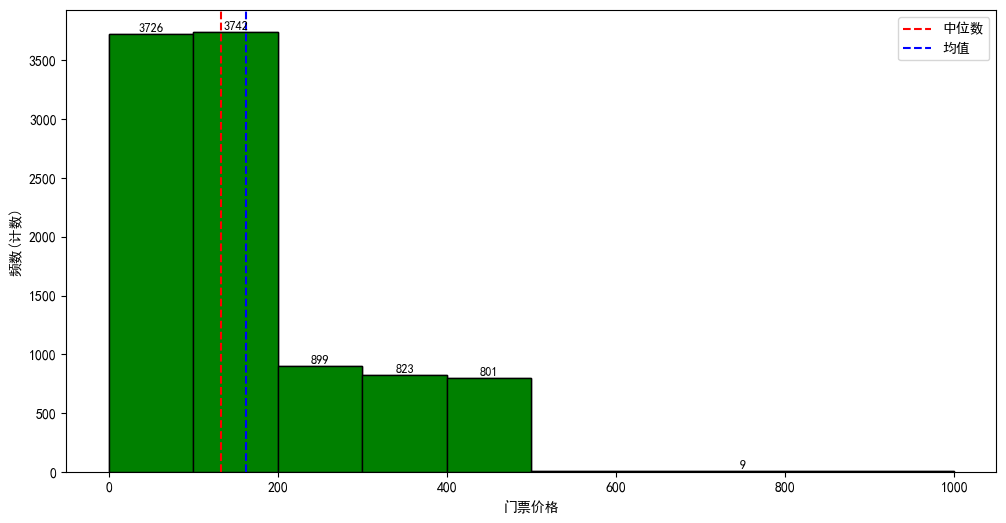

In [5]:
# ===== 门票价格分布 =====
# 计算中位数/均值，绘制直方图并标注两条参考线
# 循环为每个柱子添加频数标签
Ticket_price_median = Attraction['门票价格'].median()
Ticket_price_mean = Attraction['门票价格'].mean()
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(12,6))
plt.hist(Attraction['门票价格'],bins=[0,100,200,300,400,500,1000],color='g',edgecolor='k')
plt.xlabel('门票价格')
plt.ylabel('频数(计数)')
plt.axvline(x=Ticket_price_median,linestyle='--',color='r',label='中位数')
plt.axvline(x=Ticket_price_mean,linestyle='--',color='b',label='均值')
plt.legend()

counts,bins,patches = plt.hist(Attraction['门票价格'],bins=[0,100,200,300,400,500,1000],color='g',edgecolor='k')
for count,patch in zip(counts,patches):
    if count > 0:
        plt.text(patch.get_x() + patch.get_width()/2,count,int(count),ha='center',va='bottom',fontsize=9)
plt.show()

In [6]:
# ===== 客流对数变换 =====
# log10 变换：月均游览人次跨度大（可能从几百到百万），取对数让分布更可读
Attraction['log10_月均客流'] = np.log10(Attraction['月均游览人次'])
Attraction['log10_月均客流']

0       3.486430
1       3.208173
2       4.325926
3       3.558948
4       3.406370
          ...   
9995    4.206826
9996    4.675797
9997    4.542913
9998    4.590730
9999    3.680789
Name: log10_月均客流, Length: 10000, dtype: float64

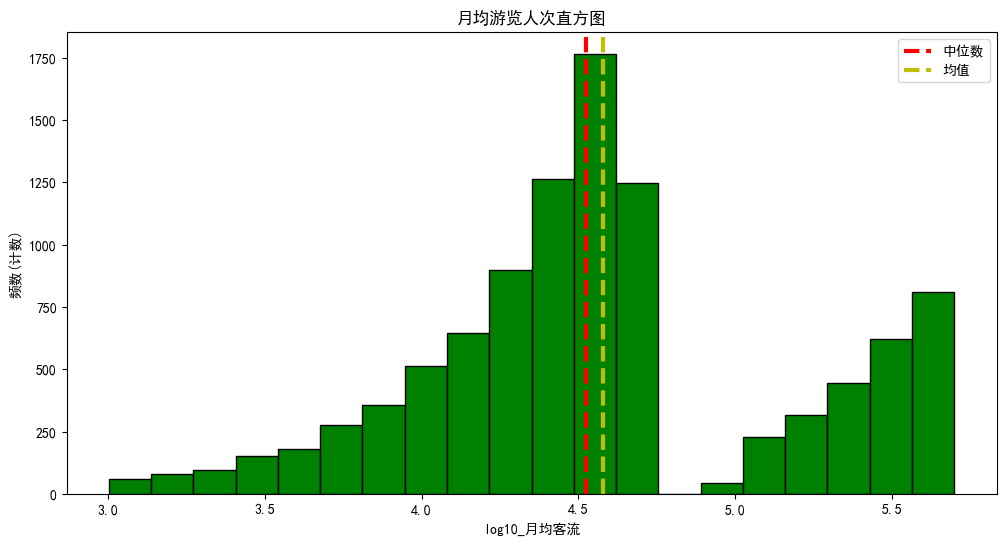

In [7]:
# 对数化后客流直方图 + 均值/中位数参考线
median = Attraction['log10_月均客流'].median()
mean = Attraction['log10_月均客流'].mean()
plt.figure(figsize=(12,6))
plt.hist(Attraction['log10_月均客流'],bins=20,color='g',edgecolor='k')
plt.xlabel('log10_月均客流')
plt.ylabel('频数(计数)')
plt.title('月均游览人次直方图')
plt.axvline(x=median,color='r',linestyle='--',linewidth=3,label='中位数')
plt.axvline(x=mean,color='y',linestyle='--',linewidth=3,label='均值')
plt.legend()
plt.show()

In [8]:
# 查看数据表
Attraction

,景点名称,景点类型,所在城市,景点负责人,景点星级,月均游览人次,日均门票销量,游客好评率,门票价格,周边酒店数量,周边餐厅数量,月开放天数,攻略提及次数,网红打卡指数,适宜游玩季节,游客年龄段占比,热度等级,log10_月均客流
0,大理古城,古镇古村,大理,杨勇,4,3065,7962,98,5,29,100,22,72579,8,春季适宜,17,热门,3.486430
1,成都大熊猫基地,自然景观,成都,赵洋,4,1615,804,69,195,384,73,31,8657,8,冬季适宜,86,热门,3.208173
2,故宫博物院,人文古迹,北京,李伟,5,21180,139,77,43,53,69,28,79676,1,秋季适宜,47,顶流,4.325926
3,外滩,城市公园,上海,蒋伟,4,3622,612,79,383,16,46,29,3264,8,春夏适宜,69,顶流,3.558948
4,鼓浪屿,古镇古村,厦门,韩静,5,2549,202,84,118,81,127,29,97312,5,四季适宜,87,热门,3.406370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,都江堰,人文古迹,成都,秦勇,5,16100,9432,62,290,99,782,28,6908,4,冬季适宜,50,热门,4.206826
9996,西湖,自然景观,杭州,秦军,5,47402,6143,72,81,8,49,31,4077,8,夏季适宜,20,顶流,4.675797
9997,西安城墙,人文古迹,西安,沈磊,5,34907,8634,84,111,31,19,31,6248,3,夏季适宜,19,热门,4.542913
9998,颐和园,人文古迹,北京,秦军,5,38970,13712,82,80,363,54,25,2449,3,夏季适宜,25,热门,4.590730


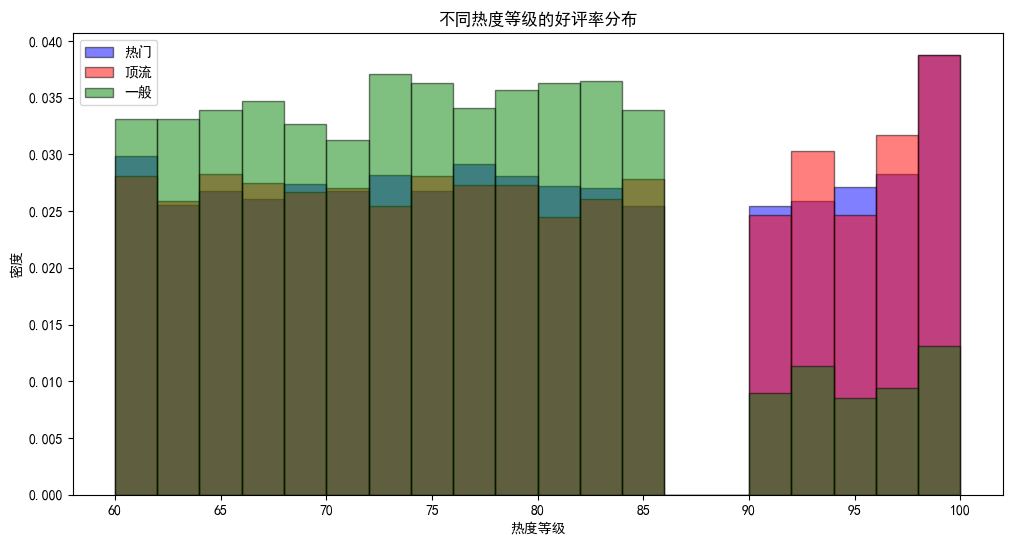

In [9]:
# ===== 不同热度等级的好评率分布 =====
# 按热度等级分组绘制密度直方图（density=True 归一化）
# 对比顶流/热门/一般景区的口碑分布
top = Attraction['热度等级'].unique()
colors = ['b','r','g']
plt.figure(figsize=(12,6))
for i,data in enumerate(top):
    Goal = Attraction[(Attraction['热度等级'] == data)]
    plt.hist(Goal['游客好评率'],
            bins=20,
            color=colors[i%len(colors)],
            edgecolor='k',
            label=f"{data}",
            alpha=0.5,
            density=True)
plt.xlabel('热度等级')
plt.ylabel('密度')
plt.title('不同热度等级的好评率分布')
plt.legend()
plt.show()

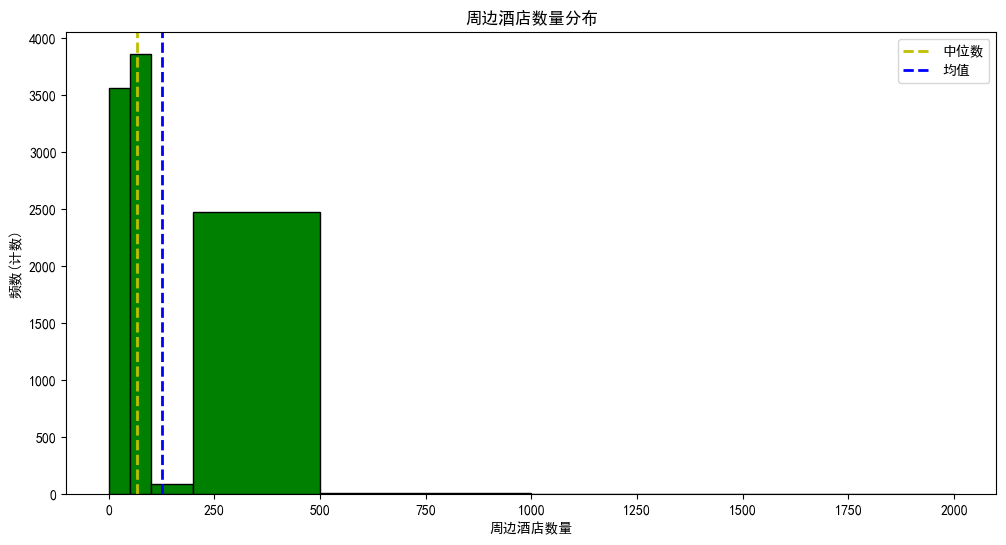

In [10]:
# ===== 周边酒店数量分布 =====
# 直方图 + 均值/中位数参考线，观察景区配套水平
Hotel_median = Attraction['周边酒店数量'].median()
Hotel_mean = Attraction['周边酒店数量'].mean()
plt.figure(figsize=(12,6))
plt.hist(Attraction['周边酒店数量'],bins=[0, 50, 100, 200, 500, 1000,2000],color='g',edgecolor='k')
plt.axvline(x=Hotel_median,linestyle='--',color='y',linewidth=2,label='中位数')
plt.axvline(x=Hotel_mean,linestyle='--',color='b',linewidth=2,label='均值')
plt.xlabel('周边酒店数量')
plt.ylabel('频数(计数)')
plt.title('周边酒店数量分布')
plt.legend()
plt.show()

In [11]:
# 查看周边酒店数量最大值
print(Attraction['周边酒店数量'].max())

500


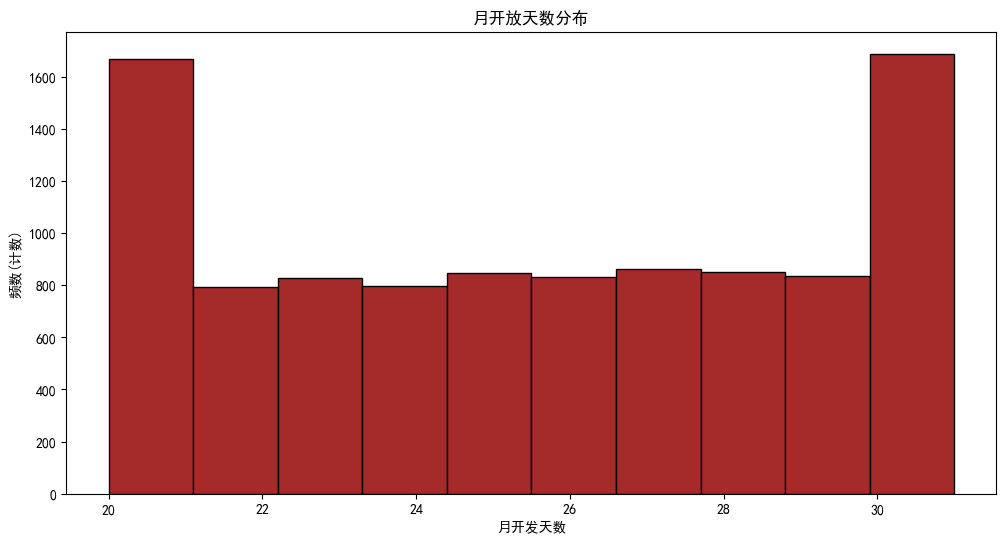

月开放天数分布结论
月开放天数中位数：26天
月开放天数均值：25.5天
最小值：20天，最大值：31天
⚠️ 存在较多景点月开放天数低于30天，建议检查是季节性闭园还是数据问题


In [12]:
# ===== 月开放天数分析 =====
# 直方图 + 统计结论（中位数/均值/最值）
# 自动判断：中位数≥30 天为正常运营，否则提示异常
plt.figure(figsize=(12,6))
plt.hist(Attraction['月开放天数'],bins=10,color='brown',edgecolor='k')
plt.xlabel('月开发天数')
plt.ylabel('频数(计数)')
plt.title('月开放天数分布')
plt.show()
print("="*60)
print("月开放天数分布结论")
print("="*60)
print(f"月开放天数中位数：{Attraction['月开放天数'].median():.0f}天")
print(f"月开放天数均值：{Attraction['月开放天数'].mean():.1f}天")
print(f"最小值：{Attraction['月开放天数'].min()}天，最大值：{Attraction['月开放天数'].max()}天")

# 判断集中度
if Attraction['月开放天数'].median() >= 30:
    print("✅ 大部分景点月开放天数集中在30天左右，属于正常运营状态")
else:
    print("⚠️ 存在较多景点月开放天数低于30天，建议检查是季节性闭园还是数据问题")


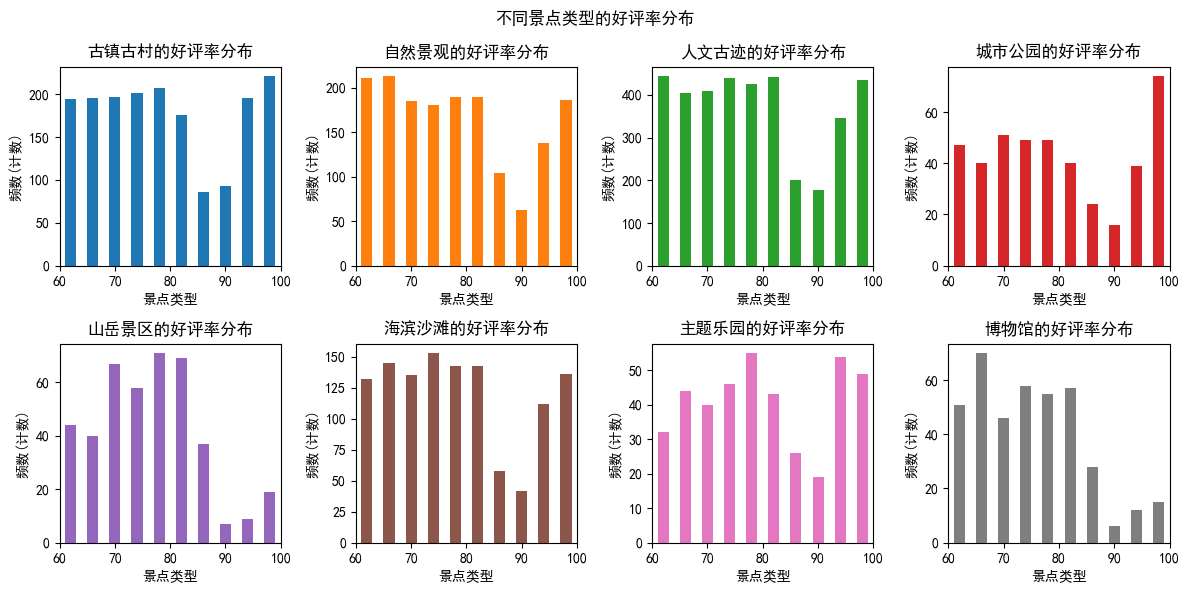

各景点类型好评率统计
      mean  median  count
景点类型                     
主题乐园  79.7    78.0    408
城市公园  79.4    78.0    429
古镇古村  78.8    77.0   1765
人文古迹  78.3    77.0   3722
海滨沙滩  78.0    77.0   1199
自然景观  77.6    77.0   1658
山岳景区  75.7    76.0    421
博物馆   74.4    74.0    398

结论：
好评率最高的景点类型：主题乐园，均值79.7%
好评率最低的景点类型：博物馆，均值74.4%
样本最多的类型：人文古迹，共3722个


In [13]:
# ===== 景点类型好评率对比 =====
# 2×4 子图分别绘制各类型好评率直方图
# 再输出各类型好评率的均值/中位数/样本数排名
attraction_group = Attraction['景点类型'].unique()
colors = plt.cm.tab10.colors
fig,axes = plt.subplots(2,4,figsize=(12,6))
fig.suptitle('不同景点类型的好评率分布')
for ax,attraction,color in zip(axes.flat,attraction_group,colors):
    data = Attraction[(Attraction['景点类型'] == attraction)]
    ax.hist(data['游客好评率'],
           bins=10,
           color=color,
           rwidth=0.5)
    ax.set_xlabel('景点类型')
    ax.set_ylabel('频数(计数)')
    ax.set_title(f"{attraction}的好评率分布")
    ax.set_xlim(60,100)
plt.tight_layout()
plt.show()
print("="*60)
print("各景点类型好评率统计")
print("="*60)

stats = Attraction.groupby('景点类型')['游客好评率'].agg(['mean', 'median', 'count']).round(1).sort_values('mean', ascending=False)
print(stats)

print("\n结论：")
print(f"好评率最高的景点类型：{stats.index[0]}，均值{stats.iloc[0]['mean']:.1f}%")
print(f"好评率最低的景点类型：{stats.index[-1]}，均值{stats.iloc[-1]['mean']:.1f}%")
print(f"样本最多的类型：{stats.loc[stats['count'].idxmax()].name}，共{stats['count'].max()}个")

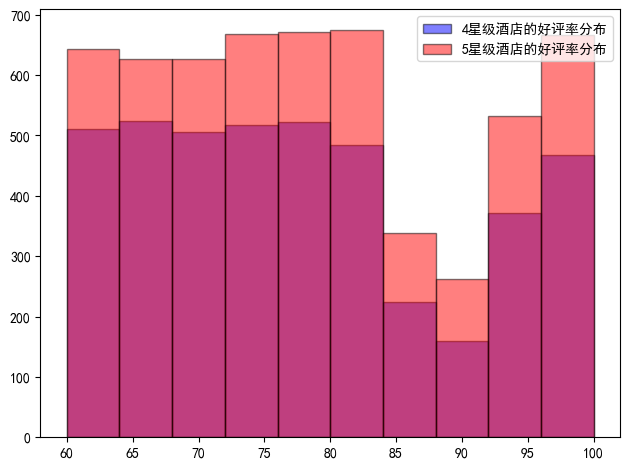

4星 vs 5星景点好评率量化对比
      mean  median  min  max  count
景点星级                               
4     77.6    76.0   60  100   4288
5     78.4    77.0   60  100   5712

5星景点均值比4星高 0.8 个百分点
⚠️ 4星和5星口碑差距不大，选4星可能更有性价比


In [14]:
# ===== 4星 vs 5星景点好评率对比 =====
# 叠加直方图 + 分组统计表
# 计算 5星-4星 好评率差值并输出结论
Attraction_Rating = Attraction['景点星级'].unique()
colors = ['b','r']
for i,Boolean_filter in enumerate(Attraction_Rating):
    data = Attraction[(Attraction['景点星级'] == Boolean_filter)]
    plt.hist(data['游客好评率'],
            bins=10,
            color=colors[i%len(colors)],
            edgecolor='k',
            label=f"{Boolean_filter}星级酒店的好评率分布",
            alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
print("="*60)
print("4星 vs 5星景点好评率量化对比")
print("="*60)

stats = Attraction.groupby('景点星级')['游客好评率'].agg(['mean', 'median', 'min', 'max', 'count']).round(1)
print(stats)

star4_mean = Attraction[Attraction['景点星级'] == 4]['游客好评率'].mean()
star5_mean = Attraction[Attraction['景点星级'] == 5]['游客好评率'].mean()

diff = star5_mean - star4_mean
print(f"\n5星景点均值比4星高 {diff:.1f} 个百分点")

if diff > 5:
    print("✅ 5星景点口碑优势明显，星级确实有品质背书作用")
else:
    print("⚠️ 4星和5星口碑差距不大，选4星可能更有性价比")

In [15]:
# ===== 高性价比景点分析 =====
# ⚠️ 顺序 bug：median_line 在 Ticket_group 定义之前使用，运行会 NameError
# 修复：把两行顺序调换即可
# 筛选好评率≥90 且门票≤100 的景点，分析其价格分布
median_line = Ticket_group['门票价格'].median()
Ticket_group = Attraction.query('游客好评率 >= 90 and 门票价格 <= 100')
plt.figure(figsize=(12,6))
plt.hist(Ticket_group['门票价格'],bins=40,color='g',edgecolor='k')
plt.xlabel('门票价格')
plt.ylabel('频数(计数)')
plt.axvline(x=median_line,color='r',linestyle='--')
plt.show()
print('--'*50)
print('高性价比景点的门票价格的分布')
print('--'*50)
group5 = Ticket_group.groupby('景点类型')['门票价格'].agg(['mean','median','min','max','count']).round(1)
print(group5)
print('更具数据得出了高性价比的景点的价格分布主要分布在40~60元之间,并且里面有免费的景点')

NameError: name 'Ticket_group' is not defined

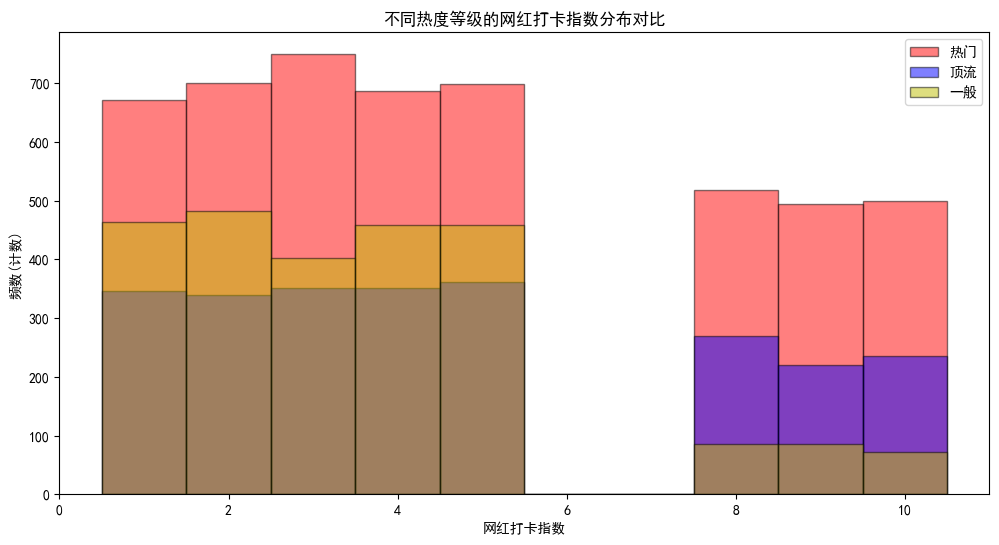

----------------------------------------------------------------------------------------------------
各景区网红打卡指数统计
----------------------------------------------------------------------------------------------------
      mean  median  min  max  count
热度等级                               
一般     3.6     3.0    1   10   2508
热门     4.8     4.0    1   10   5017
顶流     4.8     4.0    1   10   2475
从指数统计中发现顶流的景区的均值比中位数高出了0.8，意味着数据右偏，也就是说顶流的景区了存在溢价景点拉高了均值


In [16]:
# ===== 网红打卡指数分析 =====
# 按热度等级分组绘制打卡指数直方图
# 均值>中位数说明数据右偏（存在拉高均值的顶流景点）
plt.rcParams['axes.unicode_minus'] = False
Heat_unique = Attraction['热度等级'].unique()
colors = ['r','b','y']
plt.figure(figsize=(12,6))
for i,data in enumerate(Heat_unique):
    Goal2 = Attraction[(Attraction['热度等级'] == data)]
    plt.hist(Goal2['网红打卡指数'],
            bins=np.arange(0.5, 11, 1),
            color=colors[i%len(colors)],
            edgecolor='k',
            alpha=0.5,
            label=f"{data}")
plt.xlabel('网红打卡指数')
plt.ylabel('频数(计数)')
plt.title('不同热度等级的网红打卡指数分布对比')
plt.legend()
plt.show()
print('--'*50)
print('各景区网红打卡指数统计')
print('--'*50)
Heat_group = Attraction.groupby('热度等级')['网红打卡指数'].agg(['mean','median','min','max','count']).round(1)
print(Heat_group)
print('从指数统计中发现顶流的景区的均值比中位数高出了0.8，意味着数据右偏，也就是说顶流的景区了存在溢价景点拉高了均值')

In [17]:
# 查看数据表
Attraction

,景点名称,景点类型,所在城市,景点负责人,景点星级,月均游览人次,日均门票销量,游客好评率,门票价格,周边酒店数量,周边餐厅数量,月开放天数,攻略提及次数,网红打卡指数,适宜游玩季节,游客年龄段占比,热度等级,log10_月均客流
0,大理古城,古镇古村,大理,杨勇,4,3065,7962,98,5,29,100,22,72579,8,春季适宜,17,热门,3.486430
1,成都大熊猫基地,自然景观,成都,赵洋,4,1615,804,69,195,384,73,31,8657,8,冬季适宜,86,热门,3.208173
2,故宫博物院,人文古迹,北京,李伟,5,21180,139,77,43,53,69,28,79676,1,秋季适宜,47,顶流,4.325926
3,外滩,城市公园,上海,蒋伟,4,3622,612,79,383,16,46,29,3264,8,春夏适宜,69,顶流,3.558948
4,鼓浪屿,古镇古村,厦门,韩静,5,2549,202,84,118,81,127,29,97312,5,四季适宜,87,热门,3.406370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,都江堰,人文古迹,成都,秦勇,5,16100,9432,62,290,99,782,28,6908,4,冬季适宜,50,热门,4.206826
9996,西湖,自然景观,杭州,秦军,5,47402,6143,72,81,8,49,31,4077,8,夏季适宜,20,顶流,4.675797
9997,西安城墙,人文古迹,西安,沈磊,5,34907,8634,84,111,31,19,31,6248,3,夏季适宜,19,热门,4.542913
9998,颐和园,人文古迹,北京,秦军,5,38970,13712,82,80,363,54,25,2449,3,夏季适宜,25,热门,4.590730


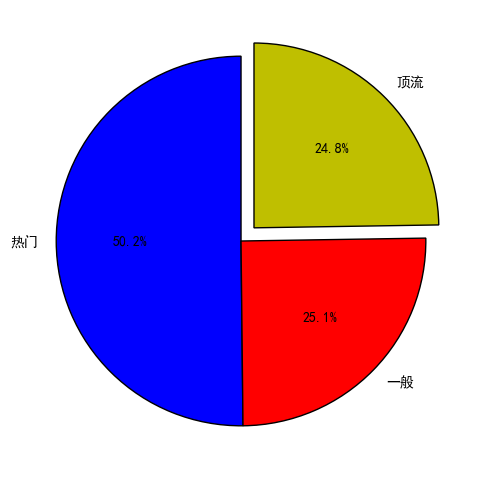

In [18]:
# 热度等级占比饼图（explode 突出某一扇区）
Heat_level_pie = Attraction['热度等级'].value_counts()
Heat_level_colors = ['b','r','y']
explode_list = [0.1 if i == 2 else 0 for i in range(len(Heat_level_pie))]
plt.figure(figsize=(12,6))
plt.pie(Heat_level_pie,
       labels=Heat_level_pie.index,
       colors=Heat_level_colors,
       wedgeprops={'edgecolor':'k','linewidth':1},
       startangle=90,
       autopct='%1.1f%%',
       explode=explode_list)
plt.show()

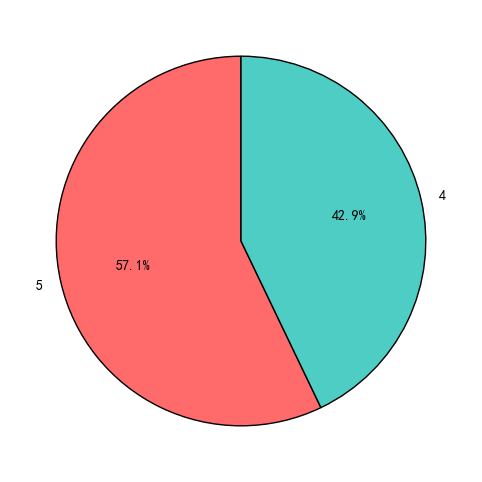

In [19]:
# 景点星级占比饼图（4星 vs 5星）
Tourist_Attraction_Rating = Attraction['景点星级'].value_counts()
plt.figure(figsize=(12,6))
plt.pie(Tourist_Attraction_Rating,
       labels=Tourist_Attraction_Rating.index,
       colors=['#ff6b6b', '#4ecdc4'],
       wedgeprops={'edgecolor':'k','linewidth':1},
       startangle=90,
       autopct='%1.1f%%')
plt.show()

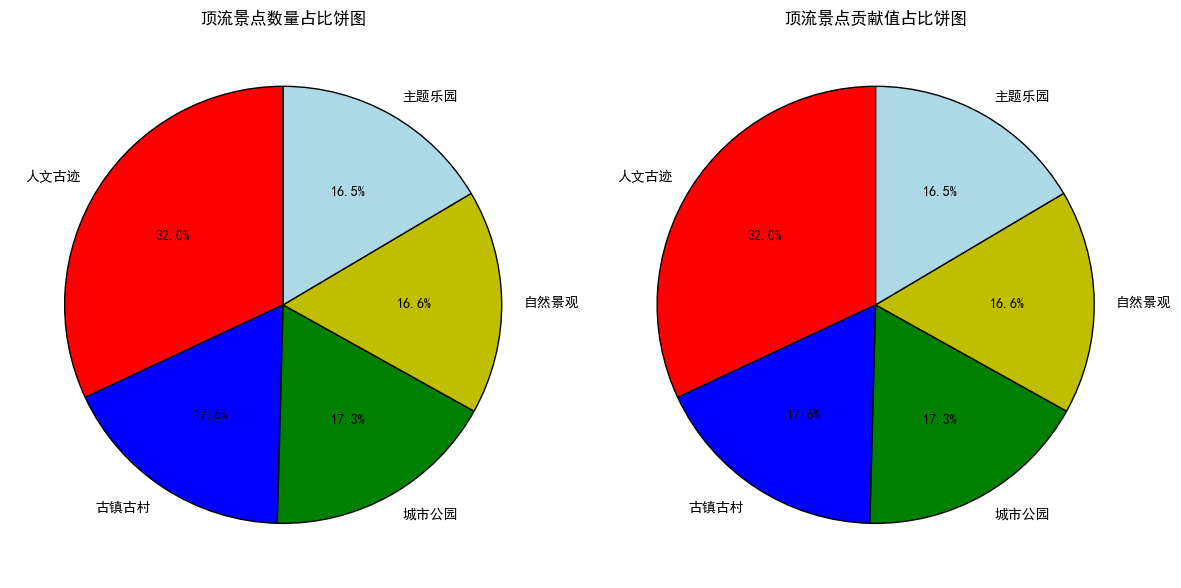

In [20]:
# ===== 顶流景点构成分析 =====
# 统计顶流景点的类型分布与贡献值（占比），双饼图展示
top_influencer = Attraction.query('热度等级 == "顶流"')
group = top_influencer['景点类型'].value_counts().reset_index()
Total = len(top_influencer)
group['贡献值(%)'] = (group['count']/Total*100).round(2)
group.rename(columns={'count':'数量'},inplace=True)
group.set_index('景点类型',inplace=True)
group_colors = ['r','b','g','y','Lightblue']
fig,axes = plt.subplots(1,2,figsize=(12,6))
axes[0].pie(group['数量'],
       labels=group.index,
       colors=group_colors,
       wedgeprops={'edgecolor':'k','linewidth':1},
       startangle=90,
       autopct='%1.1f%%')
axes[0].set_title('顶流景点数量占比饼图')
axes[1].pie(group['贡献值(%)'],
           labels=group.index,
           colors=group_colors,
           wedgeprops={'edgecolor':'k','linewidth':1},
           startangle=90,
           autopct='%1.1f%%')
axes[1].set_title('顶流景点贡献值占比饼图')
plt.tight_layout()
plt.show()

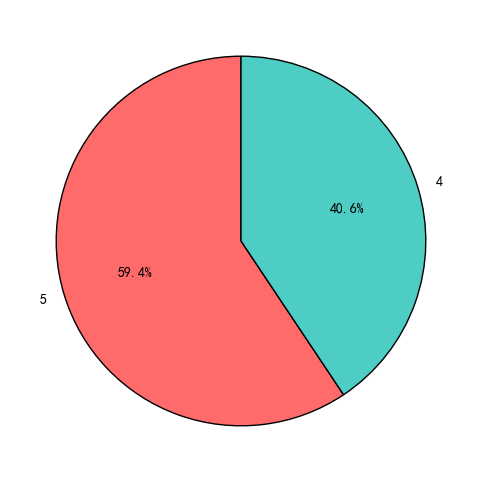

In [21]:
# 高好评率（≥90）景点的星级占比饼图
Highly_rated = Attraction.query('游客好评率 >= 90')
Highly_rated_pie = Highly_rated['景点星级'].value_counts()
plt.figure(figsize=(12,6))
plt.pie(Highly_rated_pie,
       labels=Highly_rated_pie.index,
       autopct='%1.1f%%',
       wedgeprops={'edgecolor':'k','linewidth':1},
       startangle=90,
       colors=['#ff6b6b', '#4ecdc4'])
plt.show()

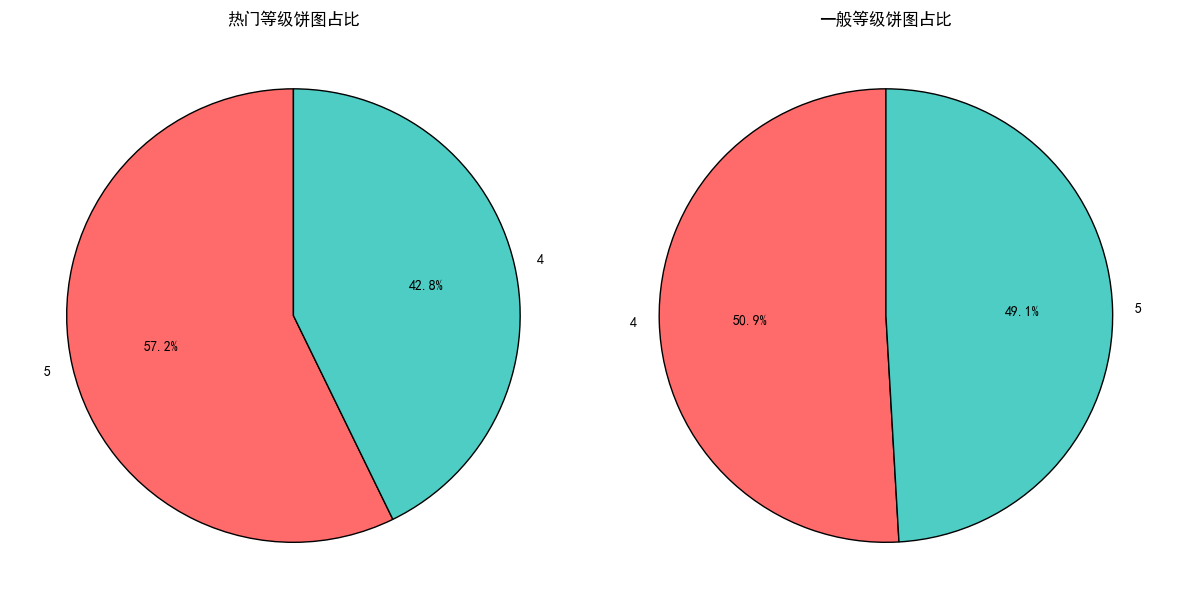

In [61]:
# 热门/一般热度等级的星级占比对比（双饼图）
pie1 = Attraction.query('热度等级 == "热门"')['景点星级'].value_counts()
pie2 = Attraction.query('热度等级 == "一般"')['景点星级'].value_counts()
pie_list = [pie1,pie2]
fig,axes = plt.subplots(1,2,figsize=(12,6))
pie_colors = ['#ff6b6b', '#4ecdc4']
ple_title = ['热门等级饼图占比','一般等级饼图占比']
for ax,data,title in zip(axes.flat,pie_list,ple_title):
    ax.pie(data,
           colors = pie_colors,
          autopct='%1.1f%%',
          startangle=90,
          wedgeprops={'edgecolor':'k','linewidth':1},
          labels=data.index)
    ax.set_title(f"{title}")
plt.tight_layout()
plt.show()

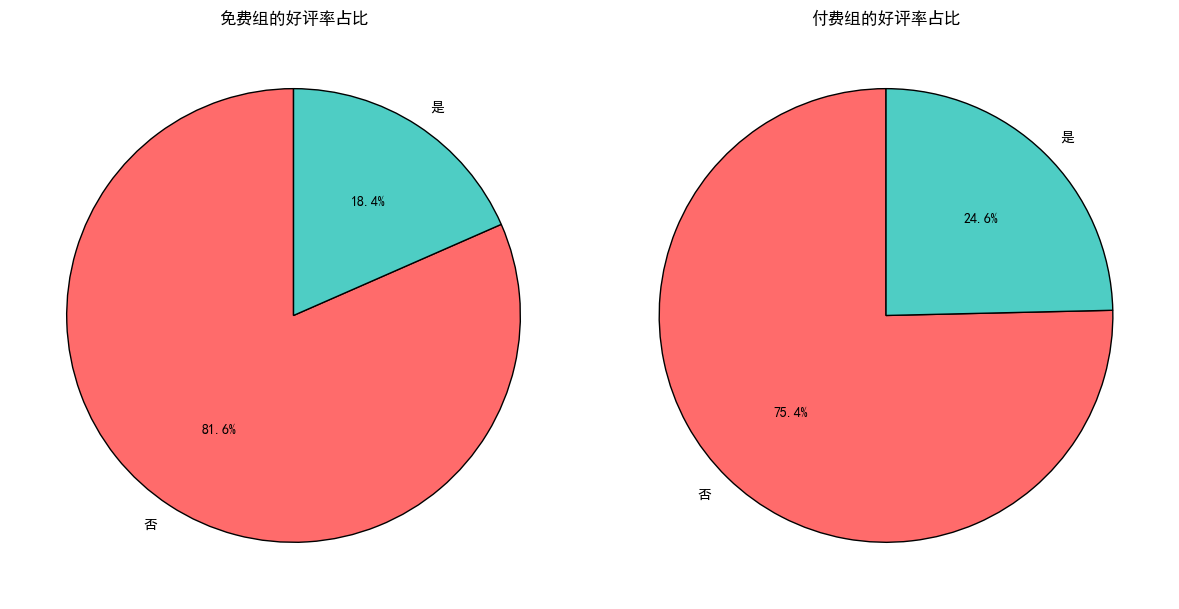

In [56]:
# ===== 好评率判断 =====
# 自定义函数：好评率≥90 标记为'是'
# apply 新增'好评率大于或等于90'列
def judgment(Positive_rating):
    if Positive_rating >= 90:
        return '是'
    else:
        return '否'
Attraction['好评率大于或等于90'] = Attraction['游客好评率'].apply(judgment)
Attraction

,景点名称,景点类型,所在城市,景点负责人,景点星级,月均游览人次,日均门票销量,游客好评率,门票价格,周边酒店数量,周边餐厅数量,月开放天数,攻略提及次数,网红打卡指数,适宜游玩季节,游客年龄段占比,热度等级,log10_月均客流,好评率大于90,好评率大于或等于90
0,大理古城,古镇古村,大理,杨勇,4,3065,7962,98,5,29,100,22,72579,8,春季适宜,17,热门,3.486430,是,是
1,成都大熊猫基地,自然景观,成都,赵洋,4,1615,804,69,195,384,73,31,8657,8,冬季适宜,86,热门,3.208173,否,否
2,故宫博物院,人文古迹,北京,李伟,5,21180,139,77,43,53,69,28,79676,1,秋季适宜,47,顶流,4.325926,否,否
3,外滩,城市公园,上海,蒋伟,4,3622,612,79,383,16,46,29,3264,8,春夏适宜,69,顶流,3.558948,否,否
4,鼓浪屿,古镇古村,厦门,韩静,5,2549,202,84,118,81,127,29,97312,5,四季适宜,87,热门,3.406370,否,否
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,都江堰,人文古迹,成都,秦勇,5,16100,9432,62,290,99,782,28,6908,4,冬季适宜,50,热门,4.206826,否,否
9996,西湖,自然景观,杭州,秦军,5,47402,6143,72,81,8,49,31,4077,8,夏季适宜,20,顶流,4.675797,否,否
9997,西安城墙,人文古迹,西安,沈磊,5,34907,8634,84,111,31,19,31,6248,3,夏季适宜,19,热门,4.542913,否,否
9998,颐和园,人文古迹,北京,秦军,5,38970,13712,82,80,363,54,25,2449,3,夏季适宜,25,热门,4.590730,否,否
